# 02 - A2C su LunarLander

Questo notebook applica la stessa implementazione A2C a `LunarLander-v3`.

LunarLander e' piu' difficile di CartPole: lo stato e' piu' ricco, le azioni restano discrete e il reward non coincide semplicemente con la durata dell'episodio. Per questo uso le stesse metriche quantitative, ma interpreto separatamente reward e lunghezza.

## Setup

Carico configurazione, moduli riutilizzabili e device. Il notebook usa lo stesso training loop di CartPole, cambiando ambiente e iperparametri. L'esecuzione usa CPU.

In [1]:
from pathlib import Path
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from torch.optim import Adam

current_dir = Path.cwd().resolve()
for candidate in [current_dir, *current_dir.parents]:
    if (candidate / "DLA_LAB3" / "src").exists():
        project_root = candidate
        break
else:
    raise RuntimeError("Eseguire il notebook dalla repository Deep_Learning_Laboratories.")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DLA_LAB3.src.a2c import train_a2c, train_vectorized_a2c
from DLA_LAB3.src.evaluation import evaluate_policy, render_policy
from DLA_LAB3.src.networks import PolicyNetwork, ValueNetwork
from DLA_LAB3.src.plotting import plot_seed_eval_curves
from DLA_LAB3.src.utils import get_device, make_vector_env, restore_model_state, seed_environment, set_seed

In [2]:
config_path = project_root / "DLA_LAB3" / "exercise_3_1_a2c" / "config_lunarlander.yaml"
with config_path.open("r", encoding="utf-8") as file:
    raw_config = yaml.safe_load(file)

CONFIG = {
    "environment_name": raw_config["environment"]["name"],
    "seeds": raw_config["training"]["seeds"],
    "num_episodes": raw_config["training"]["num_episodes"],
    "max_steps": raw_config["environment"]["max_steps"],
    "gamma": raw_config["training"]["gamma"],
    "learning_rate": raw_config["training"]["learning_rate"],
    "hidden_dim": raw_config["training"]["hidden_dim"],
    "rollout_steps": raw_config["training"]["rollout_steps"],
    "vectorized": raw_config["training"].get("vectorized", False),
    "num_envs": raw_config["training"].get("num_envs", 1),
    "vector_env_type": raw_config["training"].get("vector_env_type", "sync"),
    "value_loss_weight": raw_config["training"]["value_loss_weight"],
    "standardize_advantages": raw_config["training"]["standardize_advantages"],
    "standardize_critic_targets": raw_config["training"].get("standardize_critic_targets", False),
    "entropy_weight": raw_config["training"]["entropy_weight"],
    "evaluation_episodes": raw_config["evaluation"]["num_episodes"],
    "eval_every_n": raw_config["evaluation"]["eval_every_n"],
    "eval_episodes_m": raw_config["evaluation"]["eval_episodes_m"],
}

set_seed(CONFIG["seeds"][0])
device = get_device(force_cpu=raw_config["training"]["force_cpu"])
device

device(type='cpu')

## Ambiente LunarLander

Controllo dimensione dello stato e numero di azioni. Questi valori definiscono le dimensioni di actor e critic per l'ambiente Box2D.

In [3]:
env = gym.make(CONFIG["environment_name"])
observation, info = seed_environment(env, CONFIG["seeds"][0])

observation_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Observation iniziale:", observation)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation dim:", observation_dim)
print("Action dim:", action_dim)

Observation iniziale: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Observation dim: 8
Action dim: 4


## Training

Addestro un agente indipendente per ogni seed configurato.

L'aggiornamento A2C usa rollout brevi con bootstrap di `V(s)`. Non uso early stopping o scheduler; salvo pero' in memoria il miglior checkpoint osservato durante la valutazione periodica e lo ripristino prima della valutazione finale.

In [4]:
# Manteniamo separati risultati e modelli per confrontare i seed a parita' di configurazione.
training_results = {}
trained_actors = {}
summary_rows = []

for seed in CONFIG["seeds"]:
    print(f"Run seed {seed}")
    set_seed(seed)

    # La raccolta parallela riduce la correlazione tra transizioni consecutive.
    use_vectorized_training = CONFIG["vectorized"] and CONFIG["num_envs"] > 1
    if use_vectorized_training:
        train_env = make_vector_env(
            environment_name=CONFIG["environment_name"],
            seed=seed,
            num_envs=CONFIG["num_envs"],
            vector_env_type=CONFIG["vector_env_type"],
        )
    else:
        train_env = gym.make(CONFIG["environment_name"])
        seed_environment(train_env, seed)

    actor = PolicyNetwork(observation_dim, action_dim, CONFIG["hidden_dim"]).to(device)
    critic = ValueNetwork(observation_dim, CONFIG["hidden_dim"]).to(device)
    optimizer = Adam(
        list(actor.parameters()) + list(critic.parameters()),
        lr=CONFIG["learning_rate"],
    )

    eval_env_inter = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env_inter, seed)

    if use_vectorized_training:
        training_result = train_vectorized_a2c(
            envs=train_env,
            actor=actor,
            critic=critic,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            rollout_steps=CONFIG["rollout_steps"],
            value_loss_weight=CONFIG["value_loss_weight"],
            standardize_advantages=CONFIG["standardize_advantages"],
            standardize_critic_targets=CONFIG["standardize_critic_targets"],
            entropy_weight=CONFIG["entropy_weight"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    else:
        training_result = train_a2c(
            env=train_env,
            actor=actor,
            critic=critic,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            rollout_steps=CONFIG["rollout_steps"],
            value_loss_weight=CONFIG["value_loss_weight"],
            standardize_advantages=CONFIG["standardize_advantages"],
            standardize_critic_targets=CONFIG["standardize_critic_targets"],
            entropy_weight=CONFIG["entropy_weight"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    train_env.close()
    eval_env_inter.close()

    # Ripristiniamo insieme actor e critic selezionati dalla valutazione periodica.
    restore_model_state(actor, training_result.best_actor_state)
    restore_model_state(critic, training_result.best_critic_state)

    eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env, seed)
    evaluation = evaluate_policy(
        env=eval_env,
        policy=actor,
        device=device,
        num_episodes=CONFIG["evaluation_episodes"],
        max_steps=CONFIG["max_steps"],
        deterministic=True,
    )
    eval_env.close()

    training_results[seed] = training_result
    trained_actors[seed] = actor
    row = {
        "Seed": seed,
        "Final Train Reward": round(training_result.episode_rewards[-1], 1),
        "Best Train Reward": round(max(training_result.episode_rewards), 1),
        "Eval Mean Reward": round(evaluation["mean_reward"], 1),
        "Eval Min Reward": round(evaluation["min_reward"], 1),
        "Eval Max Reward": round(evaluation["max_reward"], 1),
        "Eval Mean Length": round(evaluation["mean_length"], 1),
        "Best Checkpoint Episode": training_result.best_eval_episode,
        "Best Checkpoint Reward": round(training_result.best_eval_mean_reward, 1),
    }
    summary_rows.append(row)
    print(row)

results_table = pd.DataFrame(summary_rows)
best_seed = int(results_table.sort_values("Eval Mean Reward", ascending=False).iloc[0]["Seed"])
best_actor = trained_actors[best_seed]

display(results_table.sort_values("Eval Mean Reward", ascending=False).reset_index(drop=True))
print("Seed migliore in valutazione:", best_seed)

Run seed 42
{'Seed': 42, 'Final Train Reward': -116.4, 'Best Train Reward': 182.7, 'Eval Mean Reward': -9.3, 'Eval Min Reward': -182.4, 'Eval Max Reward': 185.7, 'Eval Mean Length': 552.6, 'Best Checkpoint Episode': 400, 'Best Checkpoint Reward': -12.2}
Run seed 123
{'Seed': 123, 'Final Train Reward': -140.0, 'Best Train Reward': 243.5, 'Eval Mean Reward': -92.9, 'Eval Min Reward': -180.7, 'Eval Max Reward': -50.4, 'Eval Mean Length': 965.9, 'Best Checkpoint Episode': 350, 'Best Checkpoint Reward': -87.0}
Run seed 314
{'Seed': 314, 'Final Train Reward': -108.5, 'Best Train Reward': 180.4, 'Eval Mean Reward': -109.1, 'Eval Min Reward': -238.3, 'Eval Max Reward': -21.5, 'Eval Mean Length': 944.5, 'Best Checkpoint Episode': 300, 'Best Checkpoint Reward': -89.0}


,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,42,-116.4,182.7,-9.3,-182.4,185.7,552.6,400,-12.2
1,123,-140.0,243.5,-92.9,-180.7,-50.4,965.9,350,-87.0
2,314,-108.5,180.4,-109.1,-238.3,-21.5,944.5,300,-89.0


Seed migliore in valutazione: 42


## Curve di valutazione periodica

La curva mostra la valutazione deterministica eseguita a intervalli regolari. Ogni punto e' la media su episodi di valutazione, senza media mobile sui reward di training.

La curva permette di distinguere l'ultimo modello dal miglior checkpoint osservato durante il training. In LunarLander questa distinzione e' importante perche' la policy puo' peggiorare dopo aver raggiunto una fase di atterraggio piu' stabile.

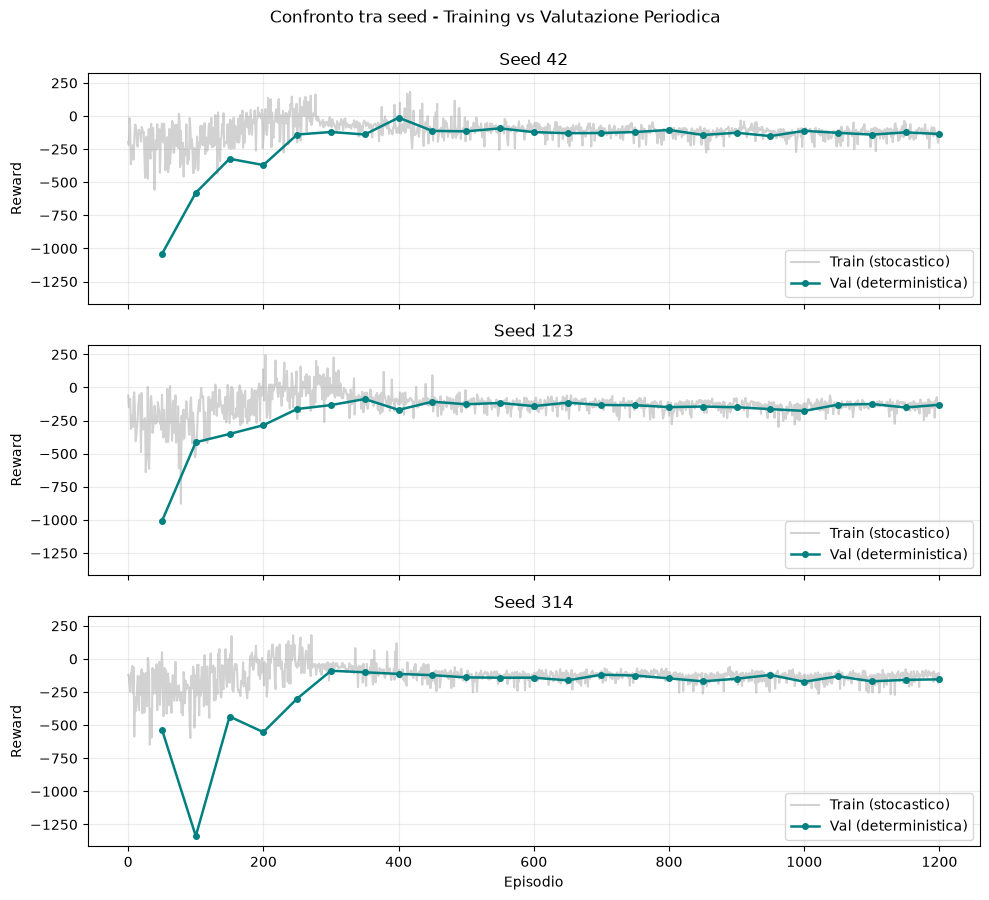

In [5]:
plot_seed_eval_curves(
    {
        seed: {
            "train_rewards": result.episode_rewards,
            "eval_intervals": result.eval_episodes,
            "eval_rewards": result.eval_mean_rewards,
        }
        for seed, result in training_results.items()
    }
)

## Analisi della Loss A2C

La loss actor e' il termine di policy gradient pesato dall'advantage, mentre la loss critic e' l'errore quadratico tra $V(s)$ e il target bootstrap n-step. Le curve sono mostrate separatamente per seed, un punto per ogni aggiornamento (rollout raccolto).

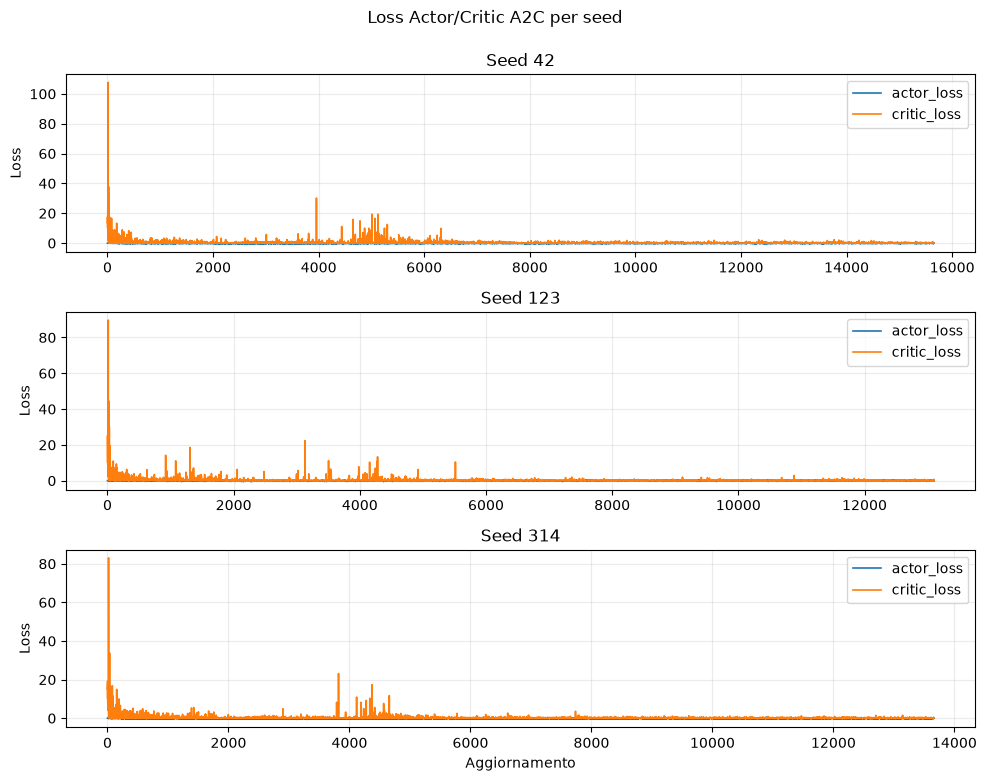

In [6]:
fig, axes = plt.subplots(
    len(training_results),
    1,
    figsize=(10, 2.6 * len(training_results)),
    sharex=False,
)

if len(training_results) == 1:
    axes = [axes]

for axis, (seed, result) in zip(axes, training_results.items()):
    axis.plot(result.actor_losses, linewidth=1.2, color="tab:blue", label="actor_loss")
    axis.plot(result.critic_losses, linewidth=1.2, color="tab:orange", label="critic_loss")
    axis.set_title(f"Seed {seed}")
    axis.set_ylabel("Loss")
    axis.legend()
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Aggiornamento")
fig.suptitle("Loss Actor/Critic A2C per seed", y=0.995)
fig.tight_layout()
plt.show()

## Risultati aggregati

La valutazione finale mostra una performance media complessiva sui tre seed di **-70.4**:
* Il **seed 42** ottiene la performance migliore con un reward medio di **-9.3** (registrando picchi positivi fino a **+185.7**).
* I **seed 123** e **314** registrano invece punteggi medi più bassi, rispettivamente pari a **-92.9** e **-109.1**.
* I migliori checkpoint per ciascun seed si osservano nelle fasi intermedie del training (episodi 400, 350 e 300), indicando che la policy tende a mostrare una certa variabilità o degrado con l'avanzare delle epoche.

La normalizzazione del target del critic (`standardize_critic_targets`) garantisce una loss del valore estremamente stabile: dopo un picco iniziale (fino a circa 100), si assesta al di sotto di 2-3 per la maggior parte dell'addestramento, a differenza delle oscillazioni nell'ordine delle migliaia che si riscontrano senza normalizzazione. La stabilità del critic, sebbene fondamentale per ridurre la varianza del gradiente, non è da sola sufficiente a guidare tutti i seed verso una convergenza ottimale e costante per un atterraggio sicuro.

Un aspect positivo riguarda la lunghezza media di valutazione (compresa tra **552.6** e **965.9 step**, con una media aggregata di **821.0 step**): questo comportamento dimostra che l'agente apprende a parzializzare la discesa e a prolungare il volo, controllando il lander nel tempo anziché schiantarsi o atterrare in modo precipitoso.

In [7]:
aggregated_table = results_table.agg(
    {
        "Eval Mean Reward": ["mean", "std", "min", "max"],
        "Eval Mean Length": ["mean", "std", "min", "max"],
    }
).round(1)

display(aggregated_table)

,Eval Mean Reward,Eval Mean Length
mean,-70.4,821.0
std,53.6,232.7
min,-109.1,552.6
max,-9.3,965.9


## Visualizzazione real time

Renderizzo la policy ripristinata dal miglior checkpoint di valutazione. La visualizzazione serve come controllo qualitativo del comportamento appreso e non modifica i pesi del modello.

Gli episodi renderizzati ottengono reward `[23.1, -93.8, -95.5]`: un atterraggio riuscito su tre, coerente con la valutazione media ancora negativa.

In [8]:
render_rewards = render_policy(
    environment_name=CONFIG["environment_name"],
    policy=best_actor,
    device=device,
    num_episodes=3,
    max_steps=CONFIG["max_steps"],
    deterministic=True,
    frame_delay=0.02,
)

print("Reward episodi renderizzati:", render_rewards)

Reward episodi renderizzati: [23.063745022940925, -93.81783809399965, -95.54415010177848]


In [9]:
env.close()